In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.feature_selection import SelectKBest, chi2 , f_classif
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression,SGDRegressor,Lasso,Ridge
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error,mean_squared_error,median_absolute_error
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv("/kaggle/input/mobile-device-usage-and-user-behavior-dataset/user_behavior_dataset.csv")

df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3


In [3]:
df.shape

(700, 11)

In [4]:
def feature_count(column):

  return df[column].value_counts()

In [5]:
df.columns

Index(['User ID', 'Device Model', 'Operating System',
       'App Usage Time (min/day)', 'Screen On Time (hours/day)',
       'Battery Drain (mAh/day)', 'Number of Apps Installed',
       'Data Usage (MB/day)', 'Age', 'Gender', 'User Behavior Class'],
      dtype='object')

In [6]:
feature_count('Operating System')

Operating System
Android    554
iOS        146
Name: count, dtype: int64

In [7]:
df[['Age']].describe()

,Age
count,700.000000
mean,38.482857
std,12.012916
min,18.000000
25%,28.000000
50%,38.000000
75%,49.000000
max,59.000000


In [8]:
def AgeGroupByAge(column):

    if column['Age'] <=30 :

        return 'young'

    elif column['Age'] <=40:

        return 'young adult'

    elif column['Age'] <= 55:

        return 'Middle adult'

    else:

        return 'old'

In [9]:
df['AgeGroup'] = df.apply(AgeGroupByAge, axis=1)

In [10]:
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class,AgeGroup
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4,young adult
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3,Middle adult
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2,Middle adult
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3,young
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3,young adult


In [11]:
df.head()

,User ID,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class,AgeGroup
0,1,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4,young adult
1,2,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3,Middle adult
2,3,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2,Middle adult
3,4,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3,young
4,5,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3,young adult


In [12]:
df.isnull().sum()

User ID                       0
Device Model                  0
Operating System              0
App Usage Time (min/day)      0
Screen On Time (hours/day)    0
Battery Drain (mAh/day)       0
Number of Apps Installed      0
Data Usage (MB/day)           0
Age                           0
Gender                        0
User Behavior Class           0
AgeGroup                      0
dtype: int64

In [13]:
df.drop('User ID', axis=1, inplace=True)

In [14]:
df.reset_index(inplace=True)

df.drop(['index'],axis = 1,inplace=True)

In [15]:
def BPlot(data,feature1,feature2 = None,hue = None) :

    fig, ax = plt.subplots(figsize=(10,6))

    if feature2 ==  None and hue == None :

        sns.boxplot(data[feature1],width=0.3,color='r')

    elif  feature2 !=  None and hue == None :

        sns.boxplot(x = data[feature1],y=data[feature2],width=0.3,color='r')

    elif  feature2 !=  None and hue != None :

        sns.boxplot(x = data[feature1],y=data[feature2],hue=data[hue],width=0.3,color='r')

    ax.set_title('Box Plot')

    plt.show()

In [16]:
df.groupby('Gender')['App Usage Time (min/day)'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,336.0,271.967262,174.232669,31.0,118.25,230.0,423.5,598.0
Male,364.0,270.354396,180.130832,30.0,104.75,222.0,445.5,595.0


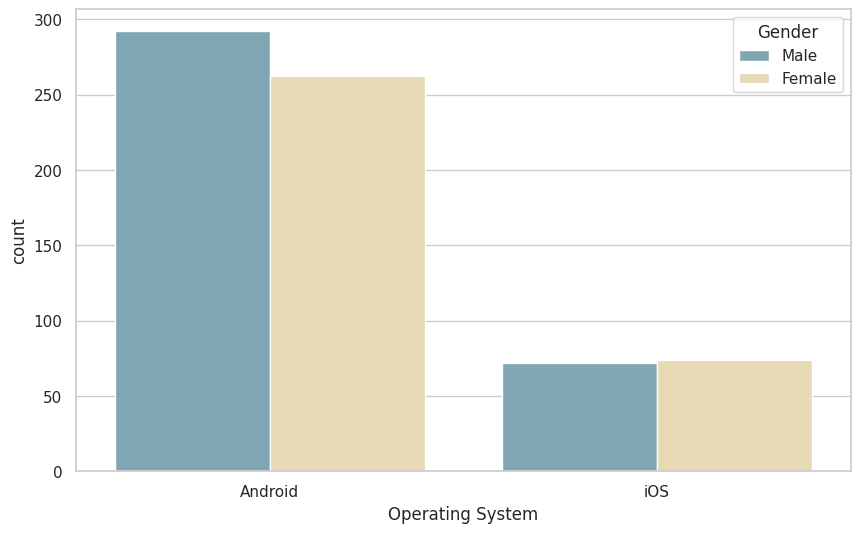

In [17]:
sns.set(style="whitegrid")

fig, ax = plt.subplots(figsize=(10,6))

ax = sns.countplot(x="Operating System", hue='Gender', data=df,palette='blend:#7AB,#EDA')

In [18]:
df['App Usage Total (week)'] = df['App Usage Time (min/day)'] * 7

In [19]:
df['App Usage to Screen Time Ratio'] = df['App Usage Time (min/day)'] / (df['Screen On Time (hours/day)'] * 60)

In [20]:
df['App Installation Category'] = pd.cut(df['Number of Apps Installed'], bins=[0, 20, 40, float('inf')],

                                         labels=['Low', 'Medium', 'High'])

In [21]:
df.head()

,Device Model,Operating System,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day),Age,Gender,User Behavior Class,AgeGroup,App Usage Total (week),App Usage to Screen Time Ratio,App Installation Category
0,Google Pixel 5,Android,393,6.4,1872,67,1122,40,Male,4,young adult,2751,1.023438,High
1,OnePlus 9,Android,268,4.7,1331,42,944,47,Female,3,Middle adult,1876,0.950355,High
2,Xiaomi Mi 11,Android,154,4.0,761,32,322,42,Male,2,Middle adult,1078,0.641667,Medium
3,Google Pixel 5,Android,239,4.8,1676,56,871,20,Male,3,young,1673,0.829861,High
4,iPhone 12,iOS,187,4.3,1367,58,988,31,Female,3,young adult,1309,0.724806,High


In [22]:
X = df.drop(['User Behavior Class'], axis=1)

y = df['User Behavior Class']

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=44, shuffle =True)

print('X_train shape is ' , X_train.shape)

print('X_test shape is ' , X_test.shape)

print('y_train shape is ' , y_train.shape)

print('y_test shape is ' , y_test.shape)

X_train shape is  (525, 13)
X_test shape is  (175, 13)
y_train shape is  (525,)
y_test shape is  (175,)


In [24]:
categorical_columns = ['Device Model', 'Operating System', 'Gender', 'AgeGroup', 'App Installation Category']


In [25]:
label_encoders = {}

for column in categorical_columns:

    le = LabelEncoder()

    X_train[column] = le.fit_transform(X_train[column])

    X_test[column] = le.transform(X_test[column])

    label_encoders[column] = le

print(f"Training Set Sample: \n{X_train.head()}")

Training Set Sample: 
     Device Model  Operating System  App Usage Time (min/day)  \
336             2                 0                       473   
689             2                 0                       541   
632             4                 1                       496   
627             4                 1                       227   
250             1                 0                        42   

     Screen On Time (hours/day)  Battery Drain (mAh/day)  \
336                         7.9                     2292   
689                         9.5                     2424   
632                        10.2                     2587   
627                         5.2                     1446   
250                         1.4                      324   

     Number of Apps Installed  Data Usage (MB/day)  Age  Gender  AgeGroup  \
336                        62                 1472   44       1         0   
689                        98                 1550   32       1         

In [26]:
print(f"Training Set Sample: \n{X_train.head()}")

Training Set Sample: 
     Device Model  Operating System  App Usage Time (min/day)  \
336             2                 0                       473   
689             2                 0                       541   
632             4                 1                       496   
627             4                 1                       227   
250             1                 0                        42   

     Screen On Time (hours/day)  Battery Drain (mAh/day)  \
336                         7.9                     2292   
689                         9.5                     2424   
632                        10.2                     2587   
627                         5.2                     1446   
250                         1.4                      324   

     Number of Apps Installed  Data Usage (MB/day)  Age  Gender  AgeGroup  \
336                        62                 1472   44       1         0   
689                        98                 1550   32       1         

In [27]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

In [28]:
X_train= pd.DataFrame(X_train)

X_train.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,-0.013257,-0.514840,1.157025,0.854407,0.940800,0.427476,0.848872,0.449864,0.994302,-1.198671,1.157025,0.850963,-0.750759
1,-0.013257,-0.514840,1.543794,1.376220,1.102150,1.774699,0.970810,-0.553018,0.994302,1.288690,1.543794,0.617586,-0.750759
2,1.378724,1.942351,1.287844,1.604513,1.301393,1.250779,1.550801,1.452747,-1.005731,-0.369551,1.287844,-0.045997,-0.750759
3,1.378724,1.942351,-0.242169,-0.026153,-0.093306,-0.171290,-0.014079,1.703468,0.994302,-0.369551,-0.242169,-0.442683,-0.750759
4,-0.709247,-0.514840,-1.294409,-1.265459,-1.464780,-1.406244,-1.027108,-0.803739,-1.005731,0.459569,-1.294409,-1.531692,0.492612


In [29]:
X_test = scaler.transform(X_test)
X_test= pd.DataFrame(X_test)

X_test.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.378724,1.942351,-0.503807,-0.384899,0.104714,-0.283558,-0.276716,-1.388753,-1.005731,0.459569,-0.503807,-0.403403,-0.750759
1,-0.709247,-0.514840,-0.975893,-1.069779,-0.730149,-0.695210,-0.737894,-0.887312,0.994302,0.459569,-0.975893,-0.016283,1.735983
2,-0.013257,-0.514840,1.765617,1.050087,1.390624,1.363047,1.353823,1.118453,0.994302,-1.198671,1.765617,1.517893,-0.750759
3,1.378724,1.942351,0.997767,0.723954,0.592431,1.026242,0.290768,-1.305180,0.994302,0.459569,0.997767,0.807887,-0.750759
4,1.378724,1.942351,1.401599,1.604513,1.723103,1.774699,0.966121,-0.636592,0.994302,1.288690,1.401599,0.110392,-0.750759


In [30]:
FeatureSelection = SelectKBest(score_func=f_classif , k=7)  # Select 7 features


X_train_selected = FeatureSelection.fit_transform(X_train, y_train)

selected_features = FeatureSelection.get_support(indices=True)

selected_feature_names = X_train.columns[selected_features]

NewData = pd.DataFrame(X_train_selected, columns=[i for i, j in zip(X_train.columns, FeatureSelection.get_support()) if j])

NewData.head()

,2,3,4,5,6,10,12
0,1.157025,0.854407,0.940800,0.427476,0.848872,1.157025,-0.750759
1,1.543794,1.376220,1.102150,1.774699,0.970810,1.543794,-0.750759
2,1.287844,1.604513,1.301393,1.250779,1.550801,1.287844,-0.750759
3,-0.242169,-0.026153,-0.093306,-0.171290,-0.014079,-0.242169,-0.750759
4,-1.294409,-1.265459,-1.464780,-1.406244,-1.027108,-1.294409,0.492612


In [31]:
X_test_selected = FeatureSelection.transform(X_test)

X_test_selected = pd.DataFrame(X_test_selected, columns=selected_feature_names)

In [32]:
param_grid = {

    'LinearRegression': {},

    'SGDRegressor': {

        'alpha': [0.01, 0.1, 0.5],

        'penalty': ['l2', 'l1', 'elasticnet']

    },

    'Lasso': {

        'alpha': [0.1, 0.5, 1.0]

    },

    'Ridge': {

        'alpha': [0.1, 0.5, 1.0, 5.0]

    },

    'RandomForestRegressor': {

        'n_estimators': [100, 500, 1000],

        'max_depth': [5, 8, 10]

    },

    'GradientBoostingRegressor': {

        'n_estimators': [100, 500],

        'learning_rate': [0.01, 0.1, 0.5],

        'max_depth': [3, 5, 7]

    },

    'SVR': {

        'C': [0.1, 1.0, 10.0],

        'epsilon': [0.01, 0.1, 0.5]

    },

    'DecisionTreeRegressor': {

        'max_depth': [3, 5, 7, 10]

    },

    'KNeighborsRegressor': {

        'n_neighbors': [3, 5, 7]

    }

}

In [33]:
model_performance = {}
for model_name in param_grid.keys():
    print(f'Performing Grid Search for {model_name}...')
    if model_name == 'LinearRegression':
        model = LinearRegression()
    elif model_name == 'SGDRegressor':
        model = SGDRegressor()
    elif model_name == 'Lasso':
        model = Lasso()
    elif model_name == 'Ridge':
        model = Ridge()
    elif model_name == 'RandomForestRegressor':
        model = RandomForestRegressor()
    elif model_name == 'GradientBoostingRegressor':
        model = GradientBoostingRegressor()
    elif model_name == 'SVR':
        model = SVR()
    elif model_name == 'DecisionTreeRegressor':
        model = DecisionTreeRegressor()
    elif model_name == 'KNeighborsRegressor':
        model = KNeighborsRegressor()
    grid_search = GridSearchCV(model, param_grid[model_name], cv=5, scoring='neg_mean_squared_error')
    grid_search.fit(X_train, y_train)
    best_model = grid_search
    best_score = grid_search
    model_performance[model_name] = {'Best Model': best_model, 'Best MSE': best_score}

    print(f'Best Model for {model_name}: {best_model}')
    print(f'Train Score is : {best_model.score(X_train, y_train)}')
    print(f'Test Score is : {best_model.score(X_test, y_test)}')
    print(f'Best MSE for {model_name}: {best_score}')

Performing Grid Search for LinearRegression...
Best Model for LinearRegression: GridSearchCV(cv=5, estimator=LinearRegression(), param_grid={},
             scoring='neg_mean_squared_error')
Train Score is : -0.028964592570512947
Test Score is : -0.03171997338912129
Best MSE for LinearRegression: GridSearchCV(cv=5, estimator=LinearRegression(), param_grid={},
             scoring='neg_mean_squared_error')
Performing Grid Search for SGDRegressor...
Best Model for SGDRegressor: GridSearchCV(cv=5, estimator=SGDRegressor(),
             param_grid={'alpha': [0.01, 0.1, 0.5],
                         'penalty': ['l2', 'l1', 'elasticnet']},
             scoring='neg_mean_squared_error')
Train Score is : -0.034603217802026826
Test Score is : -0.03657868154474574
Best MSE for SGDRegressor: GridSearchCV(cv=5, estimator=SGDRegressor(),
             param_grid={'alpha': [0.01, 0.1, 0.5],
                         'penalty': ['l2', 'l1', 'elasticnet']},
             scoring='neg_mean_squared_error'